C:\Users\alfon\AppData\Local\Temp\ipykernel_35016\2348273906.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", n_seeds)


AttributeError: PathCollection.set() got an unexpected keyword argument 'shade'

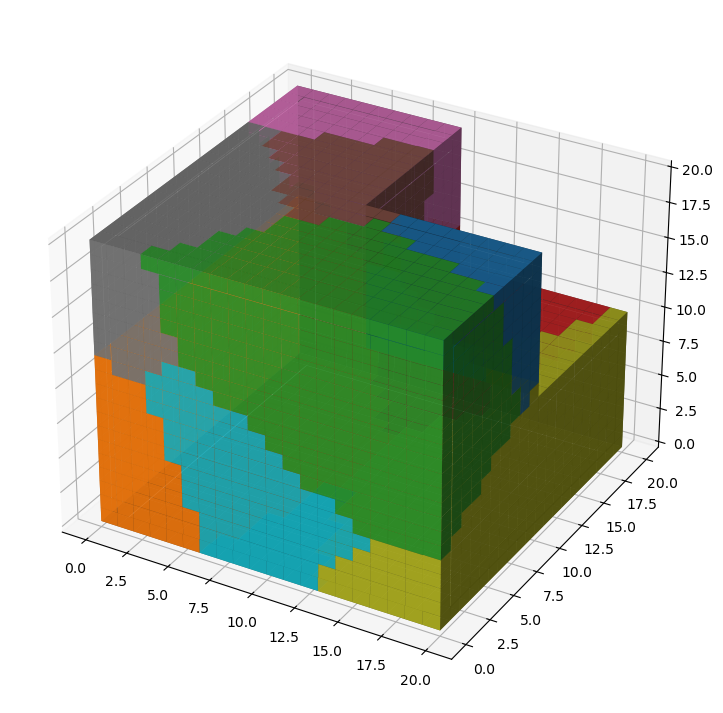

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


def compute_voronoi_labels(points, seeds):
    diff = points[:, None, :] - seeds[None, :, :]
    dist2 = np.sum(diff**2, axis=2)
    return np.argmin(dist2, axis=1)


def draw_cube_edges(ax, size):
    s = size
    corners = np.array([
        [0, 0, 0],
        [s, 0, 0],
        [s, s, 0],
        [0, s, 0],
        [0, 0, s],
        [s, 0, s],
        [s, s, s],
        [0, s, s],
    ])

    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),
        (4, 5), (5, 6), (6, 7), (7, 4),
        (0, 4), (1, 5), (2, 6), (3, 7)
    ]

    for i, j in edges:
        ax.plot(
            [corners[i, 0], corners[j, 0]],
            [corners[i, 1], corners[j, 1]],
            [corners[i, 2], corners[j, 2]],
            color="black",
            linewidth=1.0
        )


def main():
    rng = np.random.default_rng(4)

    # -----------------------------
    # Parameters
    # -----------------------------
    n_seeds = 9
    grid_res = 64          # 18-28 works well in matplotlib
    use_cutaway = True     # remove one corner so interior is visible
    alpha = 0.9

    # Seed points inside [0,1]^3
    seeds = rng.uniform(0.08, 0.92, size=(n_seeds, 3))

    # Voxel centers
    xs = np.linspace(0.0, 1.0, grid_res, endpoint=False) + 0.5 / grid_res
    ys = np.linspace(0.0, 1.0, grid_res, endpoint=False) + 0.5 / grid_res
    zs = np.linspace(0.0, 1.0, grid_res, endpoint=False) + 0.5 / grid_res

    X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")
    points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

    labels = compute_voronoi_labels(points, seeds).reshape((grid_res, grid_res, grid_res))

    # All voxels active
    filled = np.ones((grid_res, grid_res, grid_res), dtype=bool)

    # Optional cutaway: remove one octant to reveal the inside
    if use_cutaway:
        cx = grid_res // 2
        cy = grid_res // 2
        cz = grid_res // 2
        filled[cx:, cy:, cz:] = False

    # Colors per region
    cmap = cm.get_cmap("tab10", n_seeds)
    facecolors = np.zeros(filled.shape + (4,), dtype=float)

    for region_id in range(n_seeds):
        color = list(cmap(region_id))
        color[3] = alpha
        facecolors[labels == region_id] = color

    # Remove colors where voxels are not shown
    facecolors[~filled] = (0, 0, 0, 0)

    # -----------------------------
    # Plot
    # -----------------------------
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection="3d")

    ax.voxels(
        filled,
        facecolors=facecolors,
        edgecolor=(0, 0, 0, 0.08),
        linewidth=0.15,
        shade=False
    )

    # Plot seed points in voxel coordinates
    seed_plot = seeds * grid_res
    ax.scatter(
        seed_plot[:, 0],
        seed_plot[:, 1],
        seed_plot[:, 2],
        c=np.arange(n_seeds),
        cmap=cmap,
        s=90,
        edgecolors="black",
        linewidths=1.0,
        depthshade=False
    )

    draw_cube_edges(ax, grid_res)

    ax.set_title("3D Voronoi Inside a Cube (Voxel Representation)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect((1, 1, 1))

    ax.set_xlim(0, grid_res)
    ax.set_ylim(0, grid_res)
    ax.set_zlim(0, grid_res)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_axis_off()

    ax.view_init(elev=26, azim=38)
    plt.tight_layout()
    plt.savefig("voronoi_cube.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()


if __name__ == "__main__":
    main()